# DannyNet - Reproducing & Improving CheXNet on NIH ChestX-ray14

A faithful PyTorch reproduction of **DannyNet**, the improved CheXNet variant introduced by Strick, Garcia & Huang (2025) in *"Reproducing and Improving CheXNet: Deep Learning for Chest X-ray Disease Classification"* ([arXiv:2505.06646](https://arxiv.org/abs/2505.06646)).

---

## Overview

This notebook trains a **multi-label deep learning classifier** to detect **14 thoracic diseases** from frontal-view chest X-rays in the [NIH ChestX-ray14 dataset](https://www.kaggle.com/datasets/nih-chest-xrays/data) (~112,000 images, ~30,000 unique patients).

**Disease classes:**  
`Atelectasis` · `Cardiomegaly` · `Consolidation` · `Edema` · `Effusion` · `Emphysema` · `Fibrosis` · `Hernia` · `Infiltration` · `Mass` · `Nodule` · `Pleural Thickening` · `Pneumonia` · `Pneumothorax`

---

## Key Design Choices (from the paper)

| Component | Choice | Why |
|-----------|--------|-----|
| **Backbone** | DenseNet-121 (ImageNet-pretrained) | Strong baseline for medical imaging |
| **Loss** | Focal Loss (γ=2, α=1) | Handles severe class imbalance better than BCE |
| **Optimizer** | AdamW (lr=5e-5, wd=1e-4) | Decoupled weight decay → better generalization |
| **Scheduler** | ReduceLROnPlateau | Adaptive LR drops when val loss plateaus |
| **Augmentations** | RandomResizedCrop + HorizontalFlip + ColorJitter | Improves robustness |
| **Splitting** | Patient-level (70/10/20) | Prevents data leakage between sets |
| **Thresholding** | Per-class F1-optimized | Critical for imbalanced multi-label F1 |

---

## Pipeline Features

- Patient-level stratified train/val/test split with leakage assertions  
- Custom multi-label `FocalLoss` implementation  
- Weights & Biases experiment tracking  
- Best-checkpoint saving by validation AUC  
- Per-class threshold sweep on validation set  
- Per-disease AUC + F1 reporting on test set  
- Grad-CAM heatmap visualization for model interpretability  
- Final model bundle export (weights + thresholds + metrics)

---

## Expected Results

| Metric | Target (paper) |
|--------|----------------|
| Mean Test AUC | **~0.85** |
| Mean Test F1 | **~0.39** |
| Test Loss (Focal) | **~0.04** |

DannyNet outperforms the original CheXNet on **9 of 14 diseases** by AUC.

---

## Reference

> Strick, D., Garcia, C., & Huang, A. (2025). *Reproducing and Improving CheXNet: Deep Learning for Chest X-ray Disease Classification.* arXiv:2505.06646.

Original CheXNet: Rajpurkar et al. (2017), *CheXNet: Radiologist-Level Pneumonia Detection on Chest X-Rays with Deep Learning.* arXiv:1711.05225.


## Imports

In [1]:
!pip install -q grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 55.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

import torchvision.models as models
import torchvision.transforms as T

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score, f1_score
from sklearn.metrics import roc_curve

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

import wandb

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"PyTorch: {torch.__version__} | CUDA: {torch.cuda.is_available()}")

Using device: cuda
PyTorch: 2.10.0+cu128 | CUDA: True


## Configuration

In [3]:
class CFG:
    DATA_DIR    = "/kaggle/input/datasets/organizations/nih-chest-xrays/data"
    CSV_PATH    = "/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv"
    OUTPUT_DIR  = "/kaggle/working"

    IMG_SIZE    = 224

    # Training (DannyNet hyperparameters from the paper)
    BATCH_SIZE   = 32
    NUM_WORKERS  = 4
    EPOCHS       = 20
    LR           = 5e-5
    WEIGHT_DECAY = 1e-4

    # Focal Loss
    FOCAL_ALPHA  = 1.0
    FOCAL_GAMMA  = 2.0

    SEED = 42

    CLASSES = [
        "Atelectasis", "Cardiomegaly", "Consolidation", "Edema",
        "Effusion", "Emphysema", "Fibrosis", "Hernia",
        "Infiltration", "Mass", "Nodule", "Pleural_Thickening",
        "Pneumonia", "Pneumothorax",
    ]
    NUM_CLASSES = len(CLASSES)

    WANDB_PROJECT = "dannynet-chestxray14"
    RUN_NAME      = "dannynet_full_run"


def seed_everything(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


seed_everything(CFG.SEED)
os.makedirs(CFG.OUTPUT_DIR, exist_ok=True)

## Weights & Biases Login

In [4]:
USE_WANDB = False
try:
    from kaggle_secrets import UserSecretsClient
    api_key = UserSecretsClient().get_secret("WANDB_API_KEY")
    wandb.login(key=api_key)
    USE_WANDB = True
    print("wandb logged in")
except Exception as e:
    print(f"wandb disabled (no secret found): {e}")

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hamzaazharmuhammad (mhamza007) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb logged in


## Build Image Path Index

In [5]:
def build_image_paths(data_dir: str) -> dict:
    image_paths = {}
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(f"DATA_DIR does not exist: {data_dir}")

    folders = sorted(data_dir.glob("images_*"))
    if not folders:
        raise FileNotFoundError(
            f"No 'images_*' folders found in {data_dir}. "
            f"Contents: {list(data_dir.iterdir())[:10]}"
        )

    print(f"Found {len(folders)} image folders. Indexing...")
    for folder in folders:
        sub = folder / "images"
        if not sub.exists():
            print(f"  ⚠ {folder.name}: no nested 'images/' subdir, skipping")
            continue
        pngs = list(sub.glob("*.png"))
        for img in pngs:
            image_paths[img.name] = str(img)
        print(f"  {folder.name}: {len(pngs):>6} images")

    print(f"\nTotal indexed: {len(image_paths)} images")
    return image_paths


image_paths = build_image_paths(CFG.DATA_DIR)
assert len(image_paths) > 100_000, (
    f"Expected ~112k images, got {len(image_paths)}. Check CFG.DATA_DIR."
)

sample_name = "00000001_000.png"
if sample_name in image_paths:
    print(f"\nSample path: {image_paths[sample_name]}")
else:
    print(f"\nSample image '{sample_name}' not found — paths may be wrong")

Found 12 image folders. Indexing...
  images_001:   4999 images
  images_002:  10000 images
  images_003:  10000 images
  images_004:  10000 images
  images_005:  10000 images
  images_006:  10000 images
  images_007:  10000 images
  images_008:  10000 images
  images_009:  10000 images
  images_010:  10000 images
  images_011:  10000 images
  images_012:   7121 images

Total indexed: 112120 images

Sample path: /kaggle/input/datasets/organizations/nih-chest-xrays/data/images_001/images/00000001_000.png


## Load Labels and Build Multi-Hot Targets

In [6]:
df = pd.read_csv(CFG.CSV_PATH)
print(f"Total rows in CSV: {len(df)}")

# Keep only rows whose images actually exist on disk
df = df[df["Image Index"].isin(image_paths)].reset_index(drop=True)
print(f"Rows after path filtering: {len(df)}")

# Multi-hot encoding: one column per disease
for disease in CFG.CLASSES:
    df[disease] = df["Finding Labels"].apply(
        lambda labels_str: int(disease in labels_str.split("|"))
    )

df["image_path"] = df["Image Index"].map(image_paths)

print("\nDisease prevalence in full dataset:")
prev = pd.DataFrame({
    "Disease": CFG.CLASSES,
    "Count":   [df[c].sum() for c in CFG.CLASSES],
    "Percent": [df[c].mean() * 100 for c in CFG.CLASSES],
}).sort_values("Count", ascending=False)
print(prev.to_string(index=False))

Total rows in CSV: 112120
Rows after path filtering: 112120

Disease prevalence in full dataset:
           Disease  Count   Percent
      Infiltration  19894 17.743489
          Effusion  13317 11.877453
       Atelectasis  11559 10.309490
            Nodule   6331  5.646629
              Mass   5782  5.156975
      Pneumothorax   5302  4.728862
     Consolidation   4667  4.162504
Pleural_Thickening   3385  3.019087
      Cardiomegaly   2776  2.475919
         Emphysema   2516  2.244024
             Edema   2303  2.054049
          Fibrosis   1686  1.503746
         Pneumonia   1431  1.276311
            Hernia    227  0.202462


## Patient-Level Train/Val/Test Split

In [7]:
# 80/20 trainval/test, then 87.5/12.5 of trainval -> train/val (yields 70/10/20)
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=CFG.SEED)
trainval_idx, test_idx = next(gss1.split(df, groups=df["Patient ID"]))
trainval_df = df.iloc[trainval_idx].reset_index(drop=True)
test_df     = df.iloc[test_idx].reset_index(drop=True)

gss2 = GroupShuffleSplit(n_splits=1, test_size=0.125, random_state=CFG.SEED)
train_idx, val_idx = next(gss2.split(trainval_df, groups=trainval_df["Patient ID"]))
train_df = trainval_df.iloc[train_idx].reset_index(drop=True)
val_df   = trainval_df.iloc[val_idx].reset_index(drop=True)

print(f"Train: {len(train_df):>6}  ({train_df['Patient ID'].nunique()} patients)")
print(f"Val:   {len(val_df):>6}  ({val_df['Patient ID'].nunique()} patients)")
print(f"Test:  {len(test_df):>6}  ({test_df['Patient ID'].nunique()} patients)")

# Sanity check: zero patient overlap
assert not (set(train_df["Patient ID"]) & set(val_df["Patient ID"]))
assert not (set(train_df["Patient ID"]) & set(test_df["Patient ID"]))
assert not (set(val_df["Patient ID"])   & set(test_df["Patient ID"]))
print("No patient leakage between splits.")

Train:  78873  (21563 patients)
Val:    10953  (3081 patients)
Test:   22294  (6161 patients)
No patient leakage between splits.


## PyTorch Dataset

In [8]:
class ChestXrayDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform=None, classes=CFG.CLASSES):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.classes = classes

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img = Image.open(row["image_path"]).convert("RGB") 
        if self.transform is not None:
            img = self.transform(img)
        labels = torch.tensor(row[self.classes].values.astype(np.float32))
        return img, labels

## Augmentations and DataLoaders

In [9]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomResizedCrop(CFG.IMG_SIZE, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

train_ds = ChestXrayDataset(train_df, transform=train_transform)
val_ds   = ChestXrayDataset(val_df,   transform=eval_transform)
test_ds  = ChestXrayDataset(test_df,  transform=eval_transform)

train_loader = DataLoader(train_ds, batch_size=CFG.BATCH_SIZE, shuffle=True,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=CFG.BATCH_SIZE, shuffle=False,
                          num_workers=CFG.NUM_WORKERS, pin_memory=True)

# Sanity check
imgs, labels = next(iter(train_loader))
print(f"Batch images: {imgs.shape}, labels: {labels.shape}")

Batch images: torch.Size([32, 3, 224, 224]), labels: torch.Size([32, 14])


## Focal Loss (multi-label)

In [10]:
class FocalLoss(nn.Module):
    def __init__(self, alpha: float = 1.0, gamma: float = 2.0, reduction: str = "mean"):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.reduction = reduction

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
        p_t = torch.exp(-bce)
        focal = self.alpha * (1.0 - p_t) ** self.gamma * bce
        if self.reduction == "mean":
            return focal.mean()
        if self.reduction == "sum":
            return focal.sum()
        return focal

## DannyNet Model (DenseNet-121 backbone)

In [11]:
def build_dannynet(num_classes: int = 14, pretrained: bool = True) -> nn.Module:
    weights = models.DenseNet121_Weights.IMAGENET1K_V1 if pretrained else None
    model = models.densenet121(weights=weights)
    in_features = model.classifier.in_features
    model.classifier = nn.Linear(in_features, num_classes)
    return model

model = build_dannynet(CFG.NUM_CLASSES).to(device)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: DenseNet-121 → {CFG.NUM_CLASSES} logits | params: {n_params/1e6:.2f}M")

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 164MB/s] 


Model: DenseNet-121 → 14 logits | params: 6.97M


## Train / Validate Functions

In [12]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, n = 0.0, 0
    pbar = tqdm(loader, desc="train", leave=False)
    for imgs, labels in pbar:
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        logits = model(imgs)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        n += bs
        pbar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, n = 0.0, 0
    all_probs, all_targets = [], []
    for imgs, labels in tqdm(loader, desc="eval", leave=False):
        imgs   = imgs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(imgs)
        loss = criterion(logits, labels)

        bs = imgs.size(0)
        total_loss += loss.item() * bs
        n += bs
        all_probs.append(torch.sigmoid(logits).cpu().numpy())
        all_targets.append(labels.cpu().numpy())

    avg_loss = total_loss / n
    probs   = np.concatenate(all_probs,   axis=0)
    targets = np.concatenate(all_targets, axis=0)

    # Per-class AUC (skip degenerate classes)
    aucs = []
    for i in range(targets.shape[1]):
        if len(np.unique(targets[:, i])) < 2:
            aucs.append(np.nan)
        else:
            aucs.append(roc_auc_score(targets[:, i], probs[:, i]))
    mean_auc = float(np.nanmean(aucs))

    # Default 0.5-threshold F1 (real F1 reported later with tuned thresholds)
    preds_05 = (probs >= 0.5).astype(int)
    f1s_05 = [f1_score(targets[:, i], preds_05[:, i], zero_division=0)
              for i in range(targets.shape[1])]
    mean_f1 = float(np.mean(f1s_05))

    return avg_loss, mean_auc, mean_f1, probs, targets, aucs, f1s_05

## Per-Class Threshold Optimization

In [13]:
def optimize_thresholds_per_class(probs, targets, grid=None):
    """Sweep thresholds per disease and pick the one that maximizes F1 on val."""
    if grid is None:
        grid = np.arange(0.01, 0.99, 0.01)
    n_classes = targets.shape[1]
    thresholds = np.full(n_classes, 0.5)
    best_f1s   = np.zeros(n_classes)
    for i in range(n_classes):
        best_f1, best_t = 0.0, 0.5
        for t in grid:
            preds = (probs[:, i] >= t).astype(int)
            f1 = f1_score(targets[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        thresholds[i] = best_t
        best_f1s[i]   = best_f1
    return thresholds, best_f1s


def f1s_with_thresholds(probs, targets, thresholds):
    n_classes = targets.shape[1]
    return [f1_score(targets[:, i],
                     (probs[:, i] >= thresholds[i]).astype(int),
                     zero_division=0)
            for i in range(n_classes)]

## Main Training Loop

In [14]:
if USE_WANDB:
    wandb.init(
        project=CFG.WANDB_PROJECT,
        name=CFG.RUN_NAME,
        config={k: v for k, v in vars(CFG).items() if not k.startswith("__")},
    )

criterion = FocalLoss(alpha=CFG.FOCAL_ALPHA, gamma=CFG.FOCAL_GAMMA)
optimizer = AdamW(model.parameters(), lr=CFG.LR, weight_decay=CFG.WEIGHT_DECAY)
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

best_val_auc   = 0.0
best_ckpt_path = os.path.join(CFG.OUTPUT_DIR, "dannynet_best.pt")
history        = []

for epoch in range(1, CFG.EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_auc, val_f1_05, _, _, _, _ = evaluate(model, val_loader, criterion, device)
    scheduler.step(val_loss)
    lr = optimizer.param_groups[0]["lr"]

    print(f"Epoch {epoch:02d}/{CFG.EPOCHS} | "
          f"train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | "
          f"val_auc={val_auc:.4f} | val_f1@0.5={val_f1_05:.4f} | lr={lr:.2e}")

    history.append(dict(epoch=epoch, train_loss=train_loss, val_loss=val_loss,
                        val_auc=val_auc, val_f1_05=val_f1_05, lr=lr))
    if USE_WANDB:
        wandb.log(history[-1])

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "val_auc": val_auc,
        }, best_ckpt_path)
        print(f"  ✓ saved checkpoint (val_auc={val_auc:.4f})")

pd.DataFrame(history).to_csv(os.path.join(CFG.OUTPUT_DIR, "training_history.csv"), index=False)
print(f"\nDone. Best val AUC = {best_val_auc:.4f}")

wandb: Tracking run with wandb version 0.25.0
wandb: Run data is saved locally in /kaggle/working/wandb/run-20260430_133353-iwm5v26c
wandb: Run `wandb offline` to turn off syncing.
wandb: Syncing run dannynet_full_run
wandb: ⭐️ View project at https://wandb.ai/mhamza007/dannynet-chestxray14
wandb: 🚀 View run at https://wandb.ai/mhamza007/dannynet-chestxray14/runs/iwm5v26c


train:   0%|          | 0/2464 [00:00<?, ?it/s]

eval:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 01/20 | train_loss=0.0459 | val_loss=0.0418 | val_auc=0.8044 | val_f1@0.5=0.0816 | lr=5.00e-05
  ✓ saved checkpoint (val_auc=0.8044)


train:   0%|          | 0/2464 [00:00<?, ?it/s]

...

eval:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 19/20 | train_loss=0.0248 | val_loss=0.0484 | val_auc=0.8088 | val_f1@0.5=0.2263 | lr=1.56e-06


train:   0%|          | 0/2464 [00:00<?, ?it/s]

eval:   0%|          | 0/343 [00:00<?, ?it/s]

Epoch 20/20 | train_loss=0.0244 | val_loss=0.0483 | val_auc=0.8078 | val_f1@0.5=0.2229 | lr=1.56e-06

Done. Best val AUC = 0.8380


## Tune Thresholds on Val + Final Test Evaluation

In [15]:
# Reload best checkpoint
ckpt = torch.load(best_ckpt_path, map_location=device)
model.load_state_dict(ckpt["model_state_dict"])
print(f"Loaded best checkpoint (epoch {ckpt['epoch']}, val_auc {ckpt['val_auc']:.4f})")

# Recompute val probabilities for threshold tuning
_, _, _, val_probs, val_targets, _, _ = evaluate(model, val_loader, criterion, device)
thresholds, val_best_f1s = optimize_thresholds_per_class(val_probs, val_targets)

print("\nOptimized per-class thresholds (from validation set):")
for c, t, f in zip(CFG.CLASSES, thresholds, val_best_f1s):
    print(f"  {c:20s}  thr={t:.2f}  val_f1={f:.4f}")

test_loss, _, _, test_probs, test_targets, test_aucs, _ = evaluate(
    model, test_loader, criterion, device
)
test_f1s = f1s_with_thresholds(test_probs, test_targets, thresholds)

print("\n========== FINAL TEST RESULTS ==========")
print(f"Test loss        : {test_loss:.4f}")
print(f"Mean Test AUC    : {np.nanmean(test_aucs):.4f}")
print(f"Mean Test F1     : {np.mean(test_f1s):.4f}")

results_df = pd.DataFrame({
    "Disease":   CFG.CLASSES,
    "AUC":       test_aucs,
    "Threshold": thresholds,
    "F1":        test_f1s,
})
print("\nPer-disease performance:")
print(results_df.to_string(index=False))
results_df.to_csv(os.path.join(CFG.OUTPUT_DIR, "test_results.csv"), index=False)
np.save(os.path.join(CFG.OUTPUT_DIR, "thresholds.npy"), thresholds)

if USE_WANDB:
    wandb.log({
        "test_loss":     test_loss,
        "test_auc_mean": float(np.nanmean(test_aucs)),
        "test_f1_mean":  float(np.mean(test_f1s)),
    })

Loaded best checkpoint (epoch 6, val_auc 0.8380)


eval:   0%|          | 0/343 [00:00<?, ?it/s]


Optimized per-class thresholds (from validation set):
  Atelectasis           thr=0.41  val_f1=0.4084
  Cardiomegaly          thr=0.37  val_f1=0.4260
  Consolidation         thr=0.37  val_f1=0.2328
  Edema                 thr=0.35  val_f1=0.2534
  Effusion              thr=0.42  val_f1=0.5213
  Emphysema             thr=0.41  val_f1=0.4473
  Fibrosis              thr=0.30  val_f1=0.1570
  Hernia                thr=0.54  val_f1=0.5000
  Infiltration          thr=0.36  val_f1=0.3991
  Mass                  thr=0.36  val_f1=0.3768
  Nodule                thr=0.32  val_f1=0.3013
  Pleural_Thickening    thr=0.33  val_f1=0.2036
  Pneumonia             thr=0.30  val_f1=0.1220
  Pneumothorax          thr=0.33  val_f1=0.3697


eval:   0%|          | 0/697 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7ae5e80040>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
      Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7f7ae5e80040>^^
^^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
^^    ^self._shutdown_workers()
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    ^
if w.is_alive():  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive

     assert self._parent_pid == os.getpid(), 'can only test a child process' 
          ^ ^  ^ ^^^ ^ ^^^^^^^^^^
  File 


========== FINAL TEST RESULTS ==========
Test loss        : 0.0415
Mean Test AUC    : 0.8305
Mean Test F1     : 0.3119

Per-disease performance:
           Disease      AUC  Threshold       F1
       Atelectasis 0.812116       0.41 0.394533
      Cardiomegaly 0.905948       0.37 0.382353
     Consolidation 0.810381       0.37 0.228839
             Edema 0.891243       0.35 0.226237
          Effusion 0.879331       0.42 0.523817
         Emphysema 0.913711       0.41 0.437678
          Fibrosis 0.802117       0.30 0.175029
            Hernia 0.909257       0.54 0.246154
      Infiltration 0.701952       0.36 0.407975
              Mass 0.822124       0.36 0.356312
            Nodule 0.753051       0.32 0.291018
Pleural_Thickening 0.805953       0.33 0.215686
         Pneumonia 0.748880       0.30 0.088193
      Pneumothorax 0.870978       0.33 0.392516


## ROC Curves (all 14 diseases)

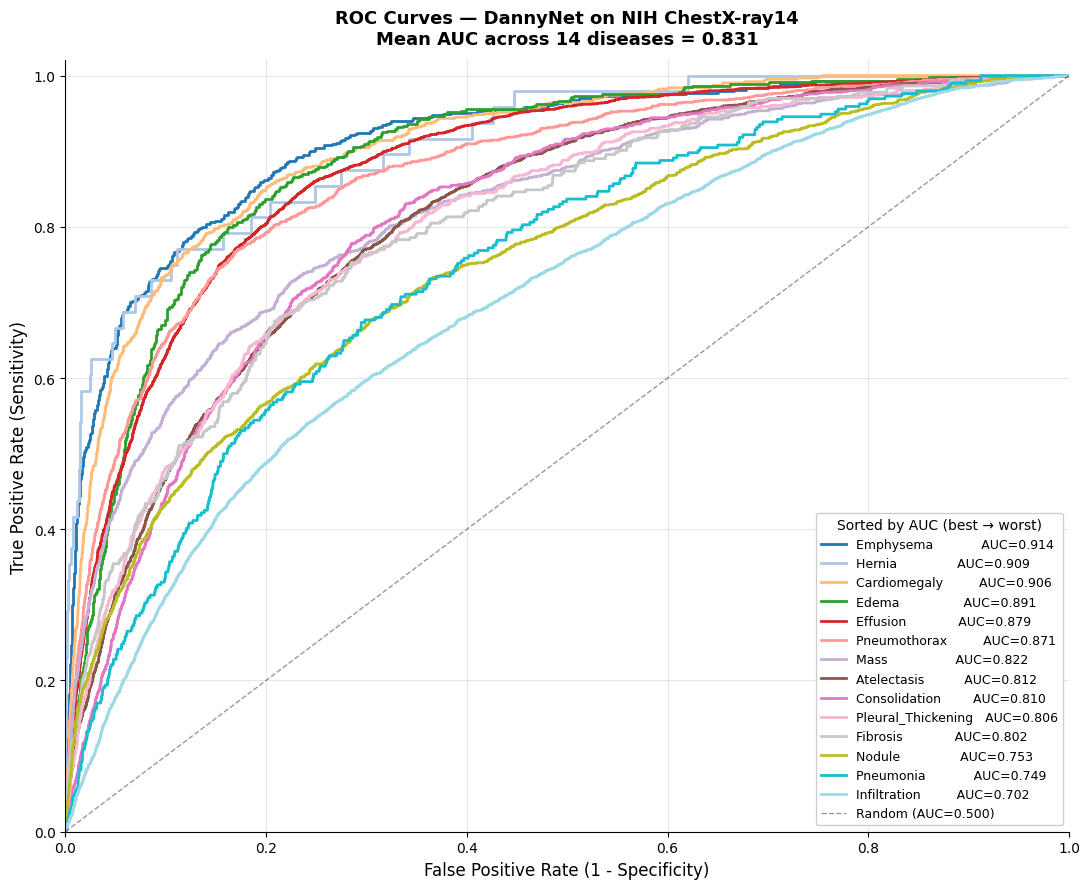


✓ ROC curves saved. Mean AUC = 0.8305


In [16]:
fig, ax = plt.subplots(figsize=(11, 9))

colors = plt.cm.tab20(np.linspace(0, 1, CFG.NUM_CLASSES))

# Sort by AUC so the legend reads top→bottom in performance order
auc_order = np.argsort(test_aucs)[::-1]

for rank, i in enumerate(auc_order):
    if np.isnan(test_aucs[i]):
        continue
    fpr, tpr, _ = roc_curve(test_targets[:, i], test_probs[:, i])
    ax.plot(fpr, tpr, color=colors[rank], linewidth=2,
            label=f"{CFG.CLASSES[i]:<20s} AUC={test_aucs[i]:.3f}")

# Random-classifier reference line
ax.plot([0, 1], [0, 1], "k--", alpha=0.4, linewidth=1, label="Random (AUC=0.500)")

mean_auc = float(np.nanmean(test_aucs))
ax.set_xlim(0, 1)
ax.set_ylim(0, 1.02)
ax.set_xlabel("False Positive Rate (1 - Specificity)", fontsize=12)
ax.set_ylabel("True Positive Rate (Sensitivity)", fontsize=12)
ax.set_title(f"ROC Curves — DannyNet on NIH ChestX-ray14\n"
             f"Mean AUC across 14 diseases = {mean_auc:.3f}",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(alpha=0.3)
ax.set_axisbelow(True)
ax.legend(loc="lower right", fontsize=9, framealpha=0.95,
          title="Sorted by AUC (best → worst)", title_fontsize=10)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "roc_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print(f"\n✓ ROC curves saved. Mean AUC = {mean_auc:.4f}")

## DannyNet vs. Original CheXNet Comparison

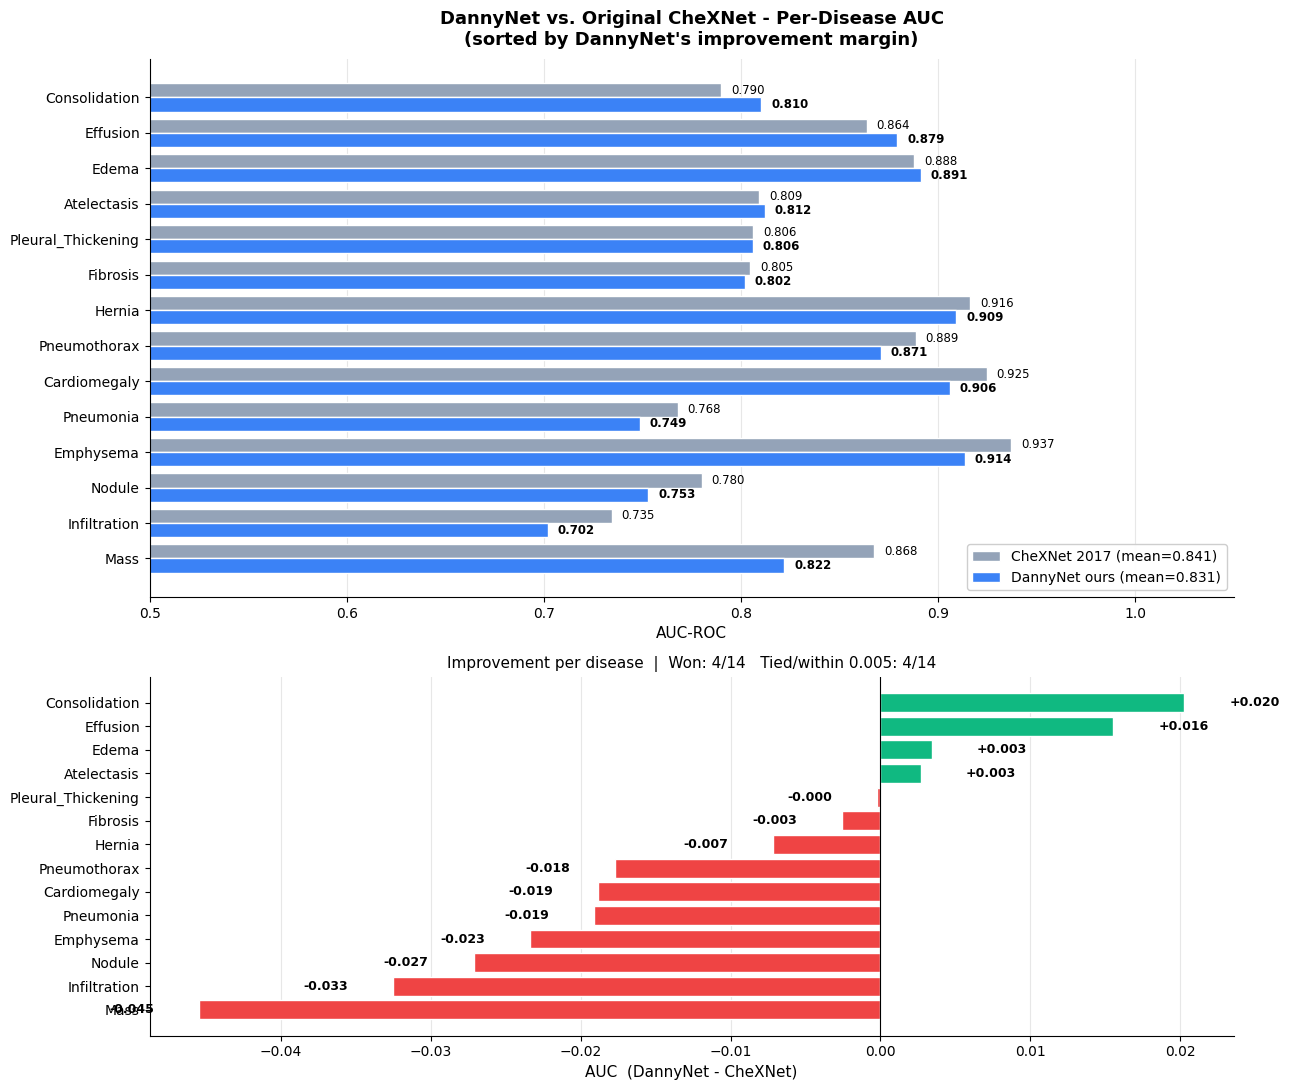


════════════════════════════════════════════════════════════════
                  DannyNet vs. CheXNet Summary
════════════════════════════════════════════════════════════════
  DannyNet mean AUC : 0.8305
  CheXNet  mean AUC : 0.8414
  Mean improvement  : -0.0109
  Beat CheXNet on   : 4 / 14 diseases
  Largest gain      : Consolidation        (+0.0203)
  Largest regression: Mass                 (-0.0455)
════════════════════════════════════════════════════════════════


In [17]:
# Original CheXNet (2017) AUC values
ORIGINAL_CHEXNET_AUC = {
    "Atelectasis":         0.8094,
    "Cardiomegaly":        0.9248,
    "Consolidation":       0.7901,
    "Edema":               0.8878,
    "Effusion":            0.8638,
    "Emphysema":           0.9371,
    "Fibrosis":            0.8047,
    "Hernia":              0.9164,
    "Infiltration":        0.7345,
    "Mass":                0.8676,
    "Nodule":              0.7802,
    "Pleural_Thickening":  0.8062,
    "Pneumonia":           0.7680,
    "Pneumothorax":        0.8887,
}

chexnet_aucs = np.array([ORIGINAL_CHEXNET_AUC[d] for d in CFG.CLASSES])
dannynet_aucs = np.array(test_aucs)
deltas = dannynet_aucs - chexnet_aucs

order = np.argsort(deltas)[::-1]
diseases_ord = [CFG.CLASSES[i] for i in order]
dannynet_ord = dannynet_aucs[order]
chexnet_ord  = chexnet_aucs[order]
deltas_ord   = deltas[order]


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 11),
                                gridspec_kw={"height_ratios": [3, 2]})

y = np.arange(len(diseases_ord))
bar_h = 0.4

ax1.barh(y - bar_h/2, chexnet_ord, bar_h,
         label=f"CheXNet 2017 (mean={chexnet_aucs.mean():.3f})",
         color="#94a3b8", edgecolor="white")
ax1.barh(y + bar_h/2, dannynet_ord, bar_h,
         label=f"DannyNet ours (mean={dannynet_aucs.mean():.3f})",
         color="#3b82f6", edgecolor="white")

for i, (c, d) in enumerate(zip(chexnet_ord, dannynet_ord)):
    ax1.text(c + 0.005, i - bar_h/2, f"{c:.3f}", va="center", fontsize=8.5)
    ax1.text(d + 0.005, i + bar_h/2, f"{d:.3f}", va="center", fontsize=8.5,
             fontweight="bold")

ax1.set_yticks(y)
ax1.set_yticklabels(diseases_ord)
ax1.invert_yaxis()
ax1.set_xlim(0.5, 1.05)
ax1.set_xlabel("AUC-ROC", fontsize=11)
ax1.set_title("DannyNet vs. Original CheXNet - Per-Disease AUC\n"
              "(sorted by DannyNet's improvement margin)",
              fontsize=13, fontweight="bold", pad=10)
ax1.legend(loc="lower right", framealpha=0.95)
ax1.grid(axis="x", alpha=0.3)
ax1.set_axisbelow(True)
for s in ("top", "right"):
    ax1.spines[s].set_visible(False)

bar_colors = ["#10b981" if d >= 0 else "#ef4444" for d in deltas_ord]
ax2.barh(y, deltas_ord, color=bar_colors, edgecolor="white")
ax2.axvline(0, color="black", linewidth=0.8)

for i, d in enumerate(deltas_ord):
    offset = 0.003 if d >= 0 else -0.003
    align = "left" if d >= 0 else "right"
    ax2.text(d + offset, i, f"{d:+.3f}", va="center", ha=align,
             fontsize=9, fontweight="bold")

ax2.set_yticks(y)
ax2.set_yticklabels(diseases_ord)
ax2.invert_yaxis()
ax2.set_xlabel("AUC  (DannyNet - CheXNet)", fontsize=11)
ax2.set_title(f"Improvement per disease  |  "
              f"Won: {(deltas > 0).sum()}/14   "
              f"Tied/within 0.005: {(np.abs(deltas) <= 0.005).sum()}/14",
              fontsize=11)
ax2.grid(axis="x", alpha=0.3)
ax2.set_axisbelow(True)
for s in ("top", "right"):
    ax2.spines[s].set_visible(False)

plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "chexnet_comparison.png"),
            dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "═" * 64)
print(" " * 18 + "DannyNet vs. CheXNet Summary")
print("═" * 64)
print(f"  DannyNet mean AUC : {dannynet_aucs.mean():.4f}")
print(f"  CheXNet  mean AUC : {chexnet_aucs.mean():.4f}")
print(f"  Mean improvement  : {deltas.mean():+.4f}")
print(f"  Beat CheXNet on   : {(deltas > 0).sum()} / 14 diseases")
print(f"  Largest gain      : {diseases_ord[0]:20s} ({deltas_ord[0]:+.4f})")
print(f"  Largest regression: {diseases_ord[-1]:20s} ({deltas_ord[-1]:+.4f})")
print("═" * 64)

## Training Curves

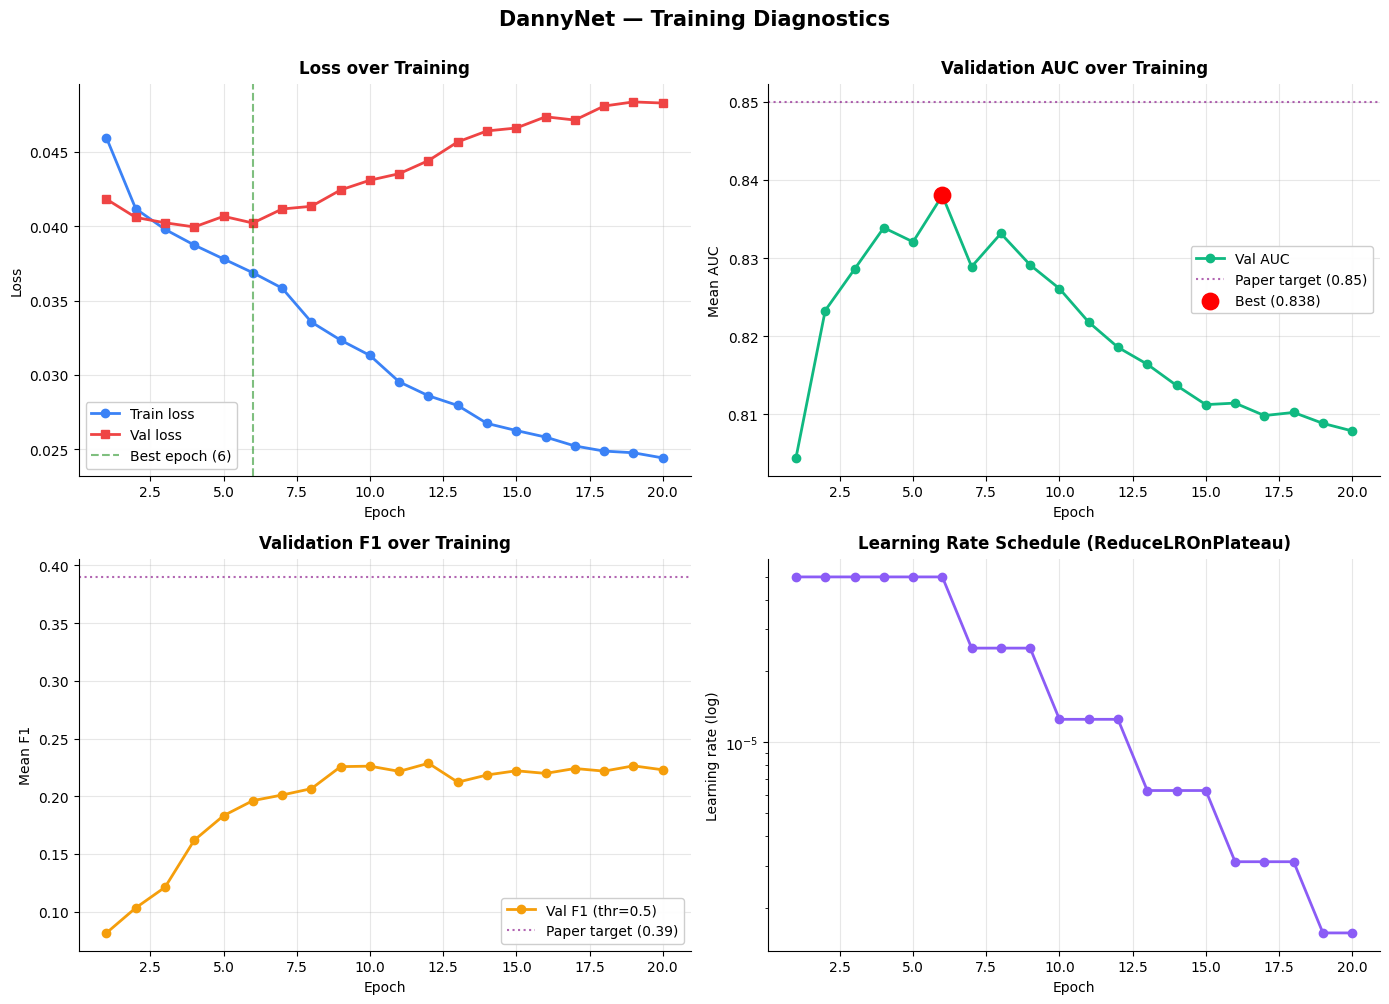


════════════════════════════════════════════════════════════
                  Training Summary
════════════════════════════════════════════════════════════
  Total epochs       : 20
  Best val AUC       : 0.8380  (epoch 6)
  Final val AUC      : 0.8078
  Final train loss   : 0.0244
  Final val loss     : 0.0483
  Initial → final LR : 5.0e-05 → 1.6e-06
════════════════════════════════════════════════════════════
  ⚠ Train/val loss gap = 0.0239 — possible overfitting


In [18]:
history_path = os.path.join(CFG.OUTPUT_DIR, "training_history.csv")
hist_df = pd.read_csv(history_path)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

best_epoch_idx = hist_df["val_auc"].idxmax()
best_epoch     = hist_df.loc[best_epoch_idx, "epoch"]
best_val_auc   = hist_df.loc[best_epoch_idx, "val_auc"]

def style(ax, title, ylabel):
    ax.set_title(title, fontsize=12, fontweight="bold", pad=8)
    ax.set_xlabel("Epoch", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)

# 1) Train vs Val Loss
ax = axes[0, 0]
ax.plot(hist_df["epoch"], hist_df["train_loss"],
        marker="o", color="#3b82f6", linewidth=2, label="Train loss")
ax.plot(hist_df["epoch"], hist_df["val_loss"],
        marker="s", color="#ef4444", linewidth=2, label="Val loss")
ax.axvline(best_epoch, color="green", linestyle="--", alpha=0.5,
           label=f"Best epoch ({best_epoch})")
ax.legend(framealpha=0.95)
style(ax, "Loss over Training", "Loss")

# 2) Validation AUC
ax = axes[0, 1]
ax.plot(hist_df["epoch"], hist_df["val_auc"],
        marker="o", color="#10b981", linewidth=2, label="Val AUC")
ax.axhline(0.85, color="purple", linestyle=":", alpha=0.6,
           label="Paper target (0.85)")
ax.scatter([best_epoch], [best_val_auc], color="red", s=140,
           zorder=5, label=f"Best ({best_val_auc:.3f})")
ax.legend(framealpha=0.95)
style(ax, "Validation AUC over Training", "Mean AUC")

# 3) Validation F1 (at default 0.5 threshold during training)
ax = axes[1, 0]
ax.plot(hist_df["epoch"], hist_df["val_f1_05"],
        marker="o", color="#f59e0b", linewidth=2, label="Val F1 (thr=0.5)")
ax.axhline(0.39, color="purple", linestyle=":", alpha=0.6,
           label="Paper target (0.39)")
ax.legend(framealpha=0.95)
style(ax, "Validation F1 over Training", "Mean F1")

# 4) Learning rate schedule
ax = axes[1, 1]
ax.plot(hist_df["epoch"], hist_df["lr"],
        marker="o", color="#8b5cf6", linewidth=2)
ax.set_yscale("log")
style(ax, "Learning Rate Schedule (ReduceLROnPlateau)", "Learning rate (log)")

plt.suptitle("DannyNet — Training Diagnostics",
             fontsize=15, fontweight="bold", y=1.00)
plt.tight_layout()
plt.savefig(os.path.join(CFG.OUTPUT_DIR, "training_curves.png"),
            dpi=150, bbox_inches="tight")
plt.show()

final_epoch = hist_df.iloc[-1]
print("\n" + "═" * 60)
print(" " * 18 + "Training Summary")
print("═" * 60)
print(f"  Total epochs       : {len(hist_df)}")
print(f"  Best val AUC       : {best_val_auc:.4f}  (epoch {best_epoch})")
print(f"  Final val AUC      : {final_epoch['val_auc']:.4f}")
print(f"  Final train loss   : {final_epoch['train_loss']:.4f}")
print(f"  Final val loss     : {final_epoch['val_loss']:.4f}")
print(f"  Initial → final LR : {hist_df.iloc[0]['lr']:.1e} → {final_epoch['lr']:.1e}")
print("═" * 60)

# Sanity check on overfitting
gap = final_epoch["val_loss"] - final_epoch["train_loss"]
if gap > 0.02:
    print(f"  ⚠ Train/val loss gap = {gap:.4f} — possible overfitting")
elif final_epoch["val_loss"] < hist_df["val_loss"].iloc[0] * 0.95:
    print(f"  ✓ Val loss dropped {(1 - final_epoch['val_loss']/hist_df['val_loss'].iloc[0])*100:.1f}% — healthy training")

## Grad-CAM Visualization

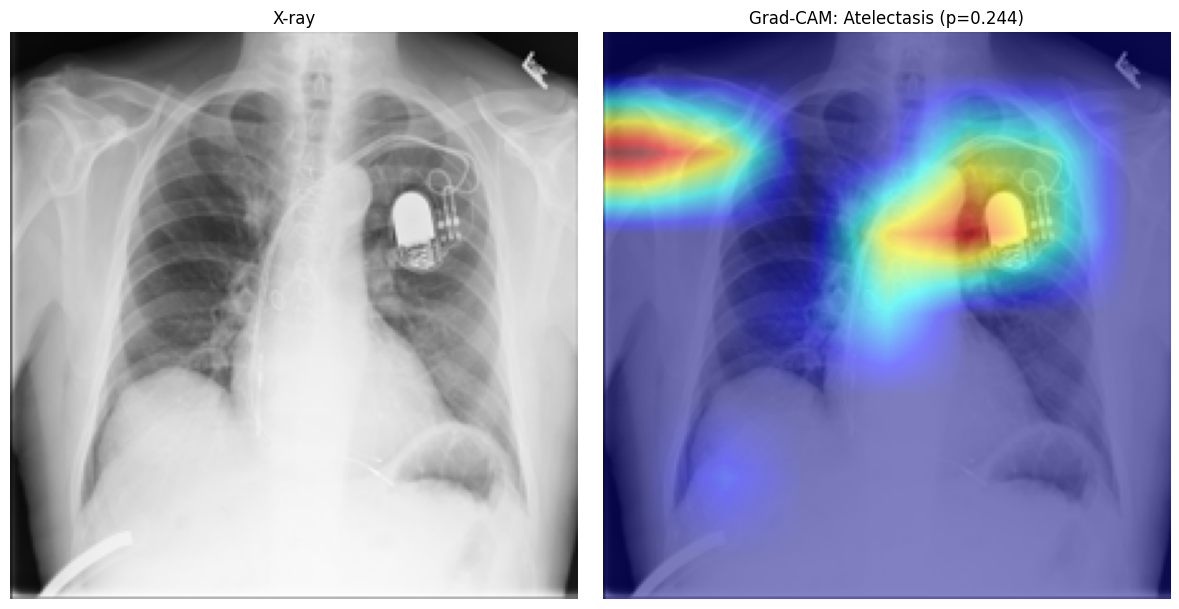


Top-5 predictions:
  Atelectasis           p=0.2440  thr=0.41  → negative
  Infiltration          p=0.2367  thr=0.36  → negative
  Cardiomegaly          p=0.2245  thr=0.37  → negative
  Nodule                p=0.2129  thr=0.32  → negative
  Effusion              p=0.1933  thr=0.42  → negative


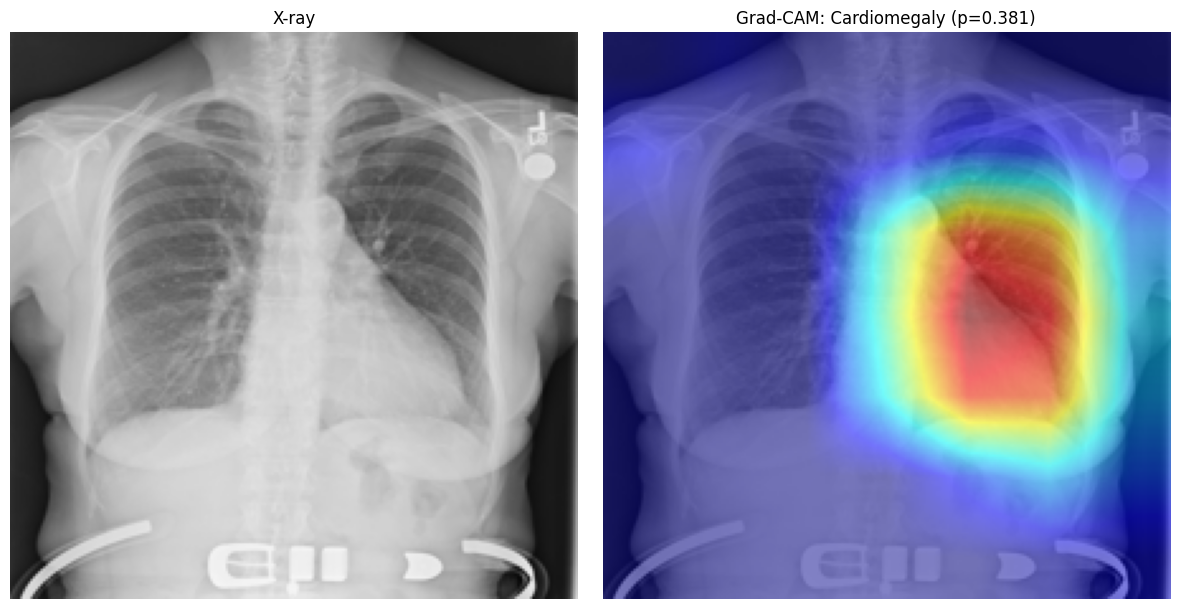


Top-5 predictions:
  Cardiomegaly          p=0.3809  thr=0.37  → POSITIVE
  Effusion              p=0.2363  thr=0.42  → negative
  Atelectasis           p=0.2218  thr=0.41  → negative
  Nodule                p=0.2143  thr=0.32  → negative
  Pleural_Thickening    p=0.2017  thr=0.33  → negative


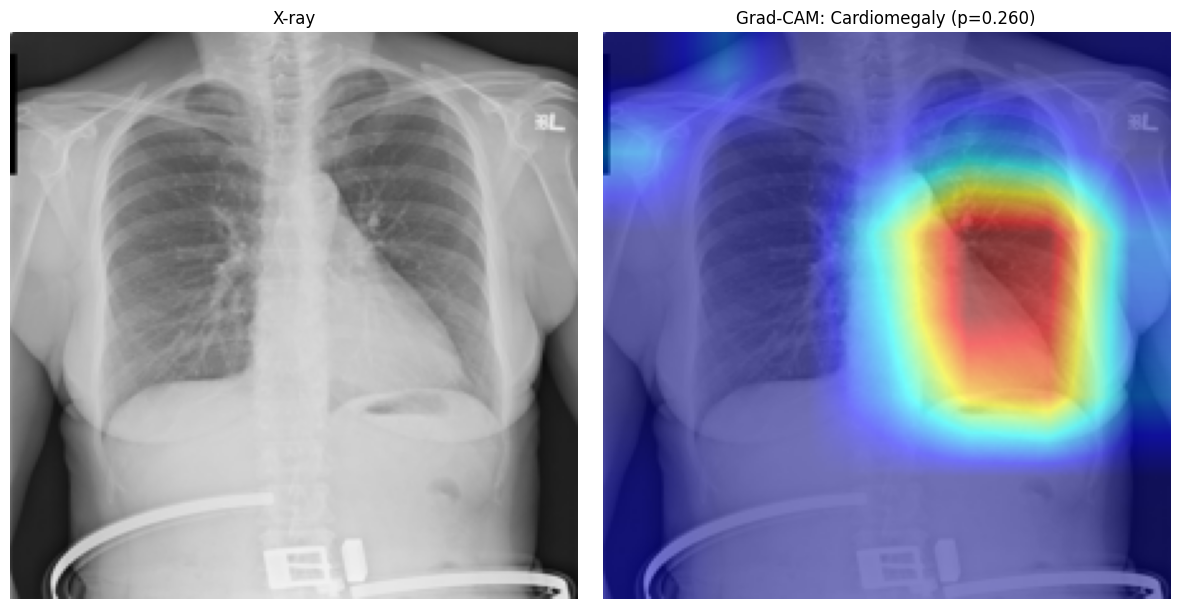


Top-5 predictions:
  Cardiomegaly          p=0.2597  thr=0.37  → negative
  Nodule                p=0.2126  thr=0.32  → negative
  Infiltration          p=0.1675  thr=0.36  → negative
  Atelectasis           p=0.1633  thr=0.41  → negative
  Pleural_Thickening    p=0.1520  thr=0.33  → negative


In [19]:
# DenseNet-121 last conv block output
target_layers = [model.features.norm5]
cam = GradCAM(model=model, target_layers=target_layers)

def visualize_gradcam(image_path: str, top_k: int = 5):
    img_pil = Image.open(image_path).convert("RGB").resize((CFG.IMG_SIZE, CFG.IMG_SIZE))
    img_np  = np.array(img_pil).astype(np.float32) / 255.0

    input_tensor = eval_transform(
        Image.open(image_path).convert("RGB")
    ).unsqueeze(0).to(device)

    # Predictions
    model.eval()
    with torch.no_grad():
        probs = torch.sigmoid(model(input_tensor))[0].cpu().numpy()

    top_idx = int(np.argmax(probs))
    targets = [ClassifierOutputTarget(top_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]
    cam_overlay = show_cam_on_image(img_np, grayscale_cam, use_rgb=True)

    fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    axes[0].imshow(img_pil); axes[0].set_title("X-ray"); axes[0].axis("off")
    axes[1].imshow(cam_overlay)
    axes[1].set_title(f"Grad-CAM: {CFG.CLASSES[top_idx]} (p={probs[top_idx]:.3f})")
    axes[1].axis("off")
    plt.tight_layout(); plt.show()

    print(f"\nTop-{top_k} predictions:")
    for i in np.argsort(probs)[::-1][:top_k]:
        flag = "POSITIVE" if probs[i] >= thresholds[i] else "negative"
        print(f"  {CFG.CLASSES[i]:20s}  p={probs[i]:.4f}  thr={thresholds[i]:.2f}  → {flag}")

for i in range(3):
    visualize_gradcam(test_df.iloc[i]["image_path"])

## Save Final Bundle

In [20]:
final_path = os.path.join(CFG.OUTPUT_DIR, "dannynet_final.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "thresholds":       thresholds.tolist(),
    "classes":          CFG.CLASSES,
    "img_size":         CFG.IMG_SIZE,
    "imagenet_mean":    IMAGENET_MEAN,
    "imagenet_std":     IMAGENET_STD,
    "test_metrics":     {
        "loss":     float(test_loss),
        "auc_mean": float(np.nanmean(test_aucs)),
        "f1_mean":  float(np.mean(test_f1s)),
        "aucs":     list(map(float, test_aucs)),
        "f1s":      list(map(float, test_f1s)),
    },
}, final_path)
print(f"Final bundle saved → {final_path}")

if USE_WANDB:
    wandb.save(final_path)
    wandb.finish()

wandb: WARNING Saving files without folders. If you want to preserve subdirectories pass base_path to wandb.save, i.e. wandb.save("/mnt/folder/file.h5", base_path="/mnt")
wandb: WARNING Symlinked 1 file into the W&B run directory; call wandb.save again to sync new files.


Final bundle saved → /kaggle/working/dannynet_final.pt


wandb: uploading working/dannynet_final.pt
wandb: 
wandb: Run history:
wandb:         epoch ▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
wandb:            lr ██████▄▄▄▃▃▃▂▂▂▁▁▁▁▁
wandb: test_auc_mean ▁
wandb:  test_f1_mean ▁
wandb:     test_loss ▁
wandb:    train_loss █▆▆▆▅▅▅▄▄▃▃▂▂▂▂▁▁▁▁▁
wandb:       val_auc ▁▅▆▇▇█▆▇▆▆▅▄▃▃▂▂▂▂▂▂
wandb:     val_f1_05 ▁▂▃▅▆▆▇▇████▇███████
wandb:      val_loss ▃▂▁▁▂▁▂▂▃▄▄▅▆▆▇▇▇███
wandb: 
wandb: Run summary:
wandb:         epoch 20
wandb:            lr 0.0
wandb: test_auc_mean 0.8305
wandb:  test_f1_mean 0.31188
wandb:     test_loss 0.04147
wandb:    train_loss 0.02442
wandb:       val_auc 0.80784
wandb:     val_f1_05 0.2229
wandb:      val_loss 0.04828
wandb: 
wandb: 🚀 View run dannynet_full_run at: https://wandb.ai/mhamza007/dannynet-chestxray14/runs/iwm5v26c
wandb: ⭐️ View project at: https://wandb.ai/mhamza007/dannynet-chestxray14
wandb: Synced 5 W&B file(s), 0 media file(s), 0 artifact file(s) and 1 other file(s)
wandb: Find logs at: ./wandb/run-20260430_133353-iwm5v26c/lo